# Kaggle

В этом домашнем задании вам нужно будет построить модель для данных соревнования [Titanic на Kaggle](https://www.kaggle.com/c/titanic/overview), сформировать файл с предсказаниями для тестовых данных и отправить его на проверку.

В практике из урока вашим заданием было разобрать одно из самых популярных ядер для соревнования Titanic и преобразовать его таким образом, чтобы остались только преобразование данных и графики.

Соответственно, сейчас ваше ядро должно выглядеть таким образом:

In [2]:
import pandas as pd
import re
import numpy as np

from sklearn.model_selection import train_test_split

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load in the train and test datasets
telecom = pd.read_csv('telecom_users.csv')


# Store our passenger ID for easy access
#PassengerId = test['PassengerId']

train.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [4]:
full_data = [train, test]

# Gives the length of the name
train['Name_length'] = train['Name'].apply(len)
test['Name_length'] = test['Name'].apply(len)
# Feature that tells whether a passenger had a cabin on the Titanic
train['Has_Cabin'] = train["Cabin"].apply(lambda x: 0 if type(x) == float else 1)
test['Has_Cabin'] = test["Cabin"].apply(lambda x: 0 if type(x) == float else 1)

# Create new feature FamilySize as a combination of SibSp and Parch
for dataset in full_data:
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1
# Create new feature IsAlone from FamilySize
for dataset in full_data:
    dataset['IsAlone'] = 0
    dataset.loc[dataset['FamilySize'] == 1, 'IsAlone'] = 1
# Remove all NULLS in the Embarked column
for dataset in full_data:
    dataset['Embarked'] = dataset['Embarked'].fillna('S')
# Remove all NULLS in the Fare column and create a new feature CategoricalFare
for dataset in full_data:
    dataset['Fare'] = dataset['Fare'].fillna(train['Fare'].median())
train['CategoricalFare'] = pd.qcut(train['Fare'], 4)
# Create a New feature CategoricalAge
for dataset in full_data:
    age_avg = dataset['Age'].mean()
    age_std = dataset['Age'].std()
    age_null_count = dataset['Age'].isnull().sum()
    age_null_random_list = np.random.randint(age_avg - age_std, age_avg + age_std, size=age_null_count)
    dataset['Age'][np.isnan(dataset['Age'])] = age_null_random_list
    dataset['Age'] = dataset['Age'].astype(int)
train['CategoricalAge'] = pd.cut(train['Age'], 5)
# Define function to extract titles from passenger names
def get_title(name):
    title_search = re.search(' ([A-Za-z]+)\.', name)
    # If the title exists, extract and return it.
    if title_search:
        return title_search.group(1)
    return ""
# Create a new feature Title, containing the titles of passenger names
for dataset in full_data:
    dataset['Title'] = dataset['Name'].apply(get_title)
# Group all non-common titles into one single grouping "Rare"
for dataset in full_data:
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')

for dataset in full_data:
    # Mapping Sex
    dataset['Sex'] = dataset['Sex'].map( {'female': 0, 'male': 1} ).astype(int)

    # Mapping titles
    title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)

    # Mapping Embarked
    dataset['Embarked'] = dataset['Embarked'].map( {'S': 0, 'C': 1, 'Q': 2} ).astype(int)

    # Mapping Fare
    dataset.loc[ dataset['Fare'] <= 7.91, 'Fare'] = 0
    dataset.loc[(dataset['Fare'] > 7.91) & (dataset['Fare'] <= 14.454), 'Fare'] = 1
    dataset.loc[(dataset['Fare'] > 14.454) & (dataset['Fare'] <= 31), 'Fare']   = 2
    dataset.loc[ dataset['Fare'] > 31, 'Fare'] = 3
    dataset['Fare'] = dataset['Fare'].astype(int)

    # Mapping Age
    dataset.loc[ dataset['Age'] <= 16, 'Age'] 					       = 0
    dataset.loc[(dataset['Age'] > 16) & (dataset['Age'] <= 32), 'Age'] = 1
    dataset.loc[(dataset['Age'] > 32) & (dataset['Age'] <= 48), 'Age'] = 2
    dataset.loc[(dataset['Age'] > 48) & (dataset['Age'] <= 64), 'Age'] = 3
    dataset.loc[ dataset['Age'] > 64, 'Age'] = 4

In [5]:
# Feature selection
drop_elements = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp']
train = train.drop(drop_elements, axis = 1)
train = train.drop(['CategoricalAge', 'CategoricalFare'], axis = 1)
test  = test.drop(drop_elements, axis = 1)

In [11]:
train.head(3)

,Survived,Pclass,Sex,Age,Parch,Fare,Embarked,Name_length,Has_Cabin,FamilySize,IsAlone,Title
0,0,3,1,1,0,0,0,23,0,2,0,1
1,1,1,0,2,0,3,1,51,1,2,0,3
2,1,3,0,1,0,1,0,22,0,1,1,2


<Axes: title={'center': 'Pearson Correlation of Features'}>

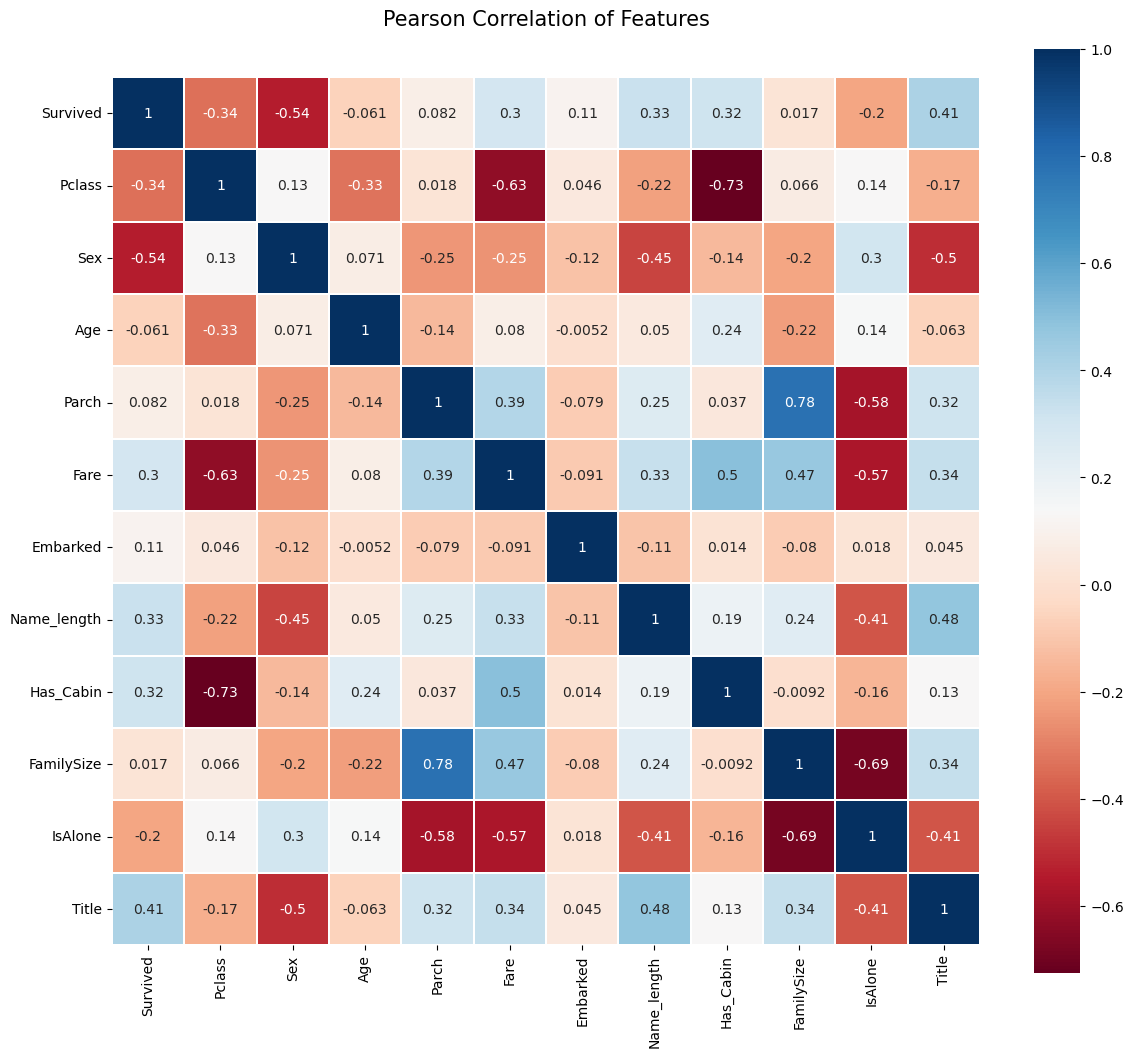

In [6]:
colormap = plt.cm.RdBu
plt.figure(figsize=(14,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.heatmap(train.astype(float).corr(),linewidths=0.1,vmax=1.0,
            square=True, cmap=colormap, linecolor='white', annot=True)

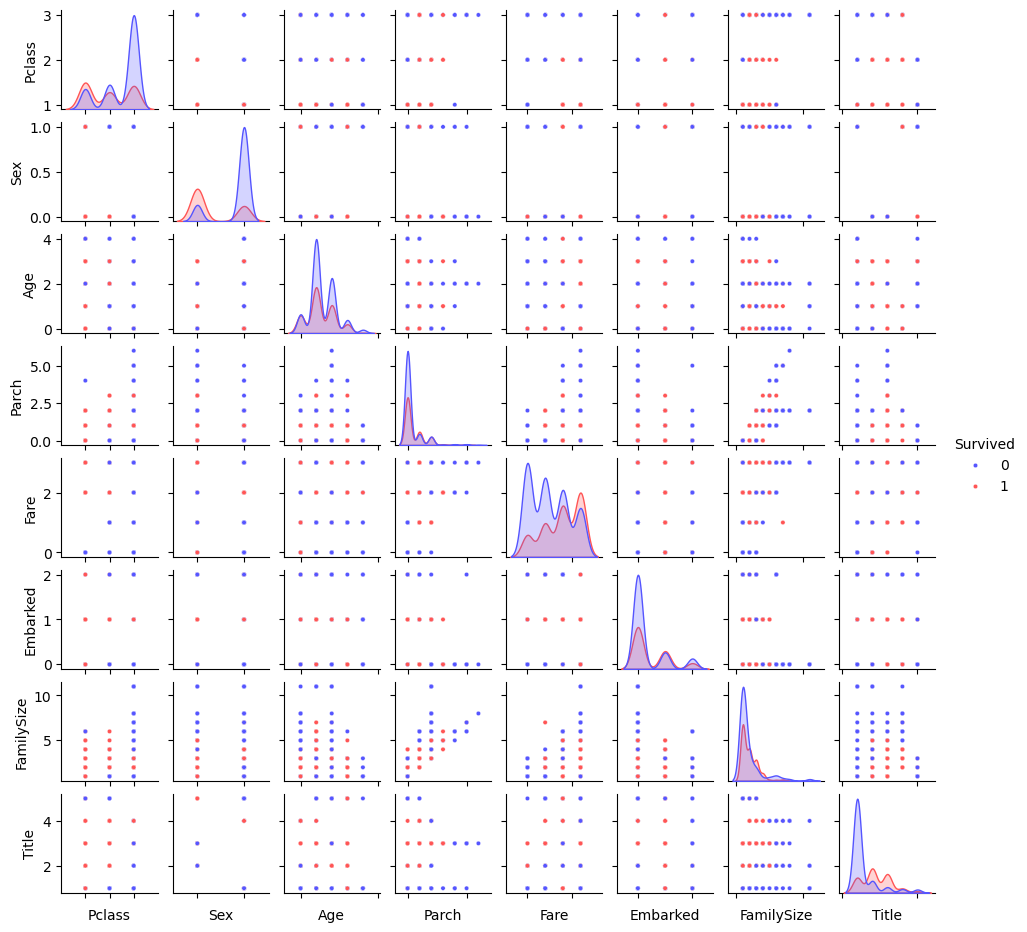

In [7]:
g = sns.pairplot(train[[u'Survived', u'Pclass', u'Sex', u'Age', u'Parch', u'Fare',
                        u'Embarked', u'FamilySize', u'Title']],
                 hue='Survived', palette = 'seismic', size=1.2, plot_kws=dict(s=10))
g.set(xticklabels=[])

Итак, у нас получились два датасета с новыми признаками. Теперь приступим к построению модели.

### Построение модели

### 1.

Воспользуйтесь вашим алгоритмом стекинга из предыдущего домашнего задания. В качестве базовых алгоритмов используйте RandomForestClassifier, SVC, GradientBoostingClassifier и LogisticRegression; в качестве мета-алгоритма - XGBoost.

Разделите данные train на тренировочную и валидационную выборки с random_state=17 и параметром разбиения test_size=.3 (в качестве целевой переменной возьмите столбец Survived, а в качестве признаков - все остальные столбцы).

Ниже приведены параметры для каждого из базовых алгоритмов, которые необходимо настроить на 5-кратной кросс-валидации с помощью GridSearchCV:

In [8]:
from sklearn.model_selection import (GridSearchCV,
                                     train_test_split,
                                     StratifiedKFold)

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

# параметры базовых алгоритмов для 5-кратной кросс-валидации с помощью GridSearchCV
gbc_params = {'learning_rate': np.arange(0.1, 0.6, 0.1)} # GradientBoostingClassifier

rfc_params = {'n_estimators': range(10, 100, 10), # RandomForestClassifier
              'min_samples_leaf': range(1, 5)}

svc_params = {'kernel': ['linear', 'rbf'], # SVC
              'C': np.arange(0.1, 1, 0.2)}

lr_params = {'C': np.arange(0.5, 1, 0.1)}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)

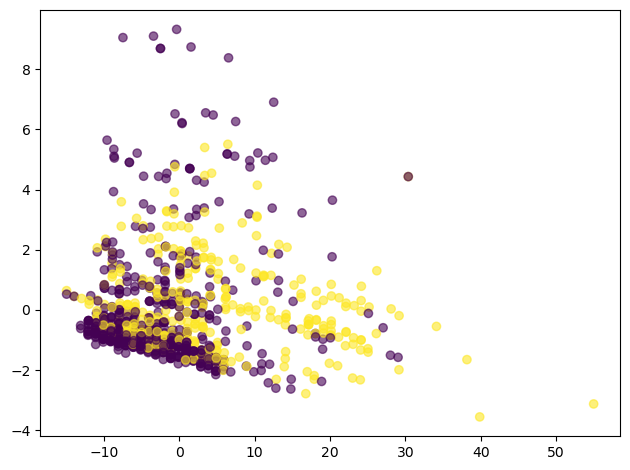

In [9]:
#выделяем целевую переменную и признаки
X = train.drop('Survived', axis=1)  #все кроме Survived
y = train['Survived']  
#разделение train на тренировочную и валидационную выборки
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=17
)
#визуализация выборки
#применяем PCA для уменьшения размерности до 2D
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6)


plt.tight_layout()
plt.show()

In [10]:
#Обучtение каждого из объектов из 1-го пункта на получившейся при разбиении тренировочной выборке
lr = LogisticRegression(random_state=17)
lr_grid = GridSearchCV(lr, lr_params, cv=skf, scoring='accuracy')
lr_grid.fit(X_train, y_train)

rfc = RandomForestClassifier(random_state=17)
rfc_grid = GridSearchCV(rfc, rfc_params, cv=skf, scoring='accuracy')
rfc_grid.fit(X_train, y_train)

gbc = GradientBoostingClassifier(random_state=17)
gbc_grid = GridSearchCV(gbc, gbc_params, cv=skf, scoring='accuracy')
gbc_grid.fit(X_train, y_train)

svc = SVC(random_state=17)
svc_grid = GridSearchCV(svc, svc_params, cv=skf, scoring='accuracy')
svc_grid.fit(X_train, y_train)

,estimator,SVC(random_state=17)
,param_grid,"{'C': array([0.1, 0....5, 0.7, 0.9]), 'kernel': ['linear', 'rbf']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.1


### 2.
1. Определите объект GridSearchCV для всех приведенных параметров каждого алгоритма (в гиперпараметрах алгоритма при его определении, если возможно, укажите random_state=17). Параметр cv устанавливайте равным skf.

2. Обучите каждый из объектов из 1-го пункта на получившейся при разбиении тренировочной выборке. Выведите лучшее сочетание параметров для каждого из алгоритмов.

3. Для каждого обученного алгоритма получите предсказания на валидационных данных и выведите метрику качества, которая соответствует метрике оценки соревнования.

In [11]:
#вывод лучших параметров
print("GBC best params:", gbc_grid.best_params_)
print("RFC best params:", rfc_grid.best_params_) 
print("SVC best params:", svc_grid.best_params_)
print("LR best params:", lr_grid.best_params_)

GBC best params: {'learning_rate': 0.4}
RFC best params: {'min_samples_leaf': 3, 'n_estimators': 30}
SVC best params: {'C': 0.1, 'kernel': 'linear'}
LR best params: {'C': 0.5}


In [12]:
#создаем модели с лучшими параметрами из GridSearch
lr_best = LogisticRegression(C=0.5, random_state=17)
rfc_best = RandomForestClassifier(min_samples_leaf=2, n_estimators=70, random_state=17)
gbc_best = GradientBoostingClassifier(learning_rate=0.1, random_state=17)
svc_best = SVC(C=0.1, kernel='linear', random_state=17, probability=True)

In [13]:
#обучаем модели
models = [lr_best, rfc_best, gbc_best, svc_best]
for model in models:
    model.fit(X_train, y_train)

### 3.
С помощью GridSearchCV и указанных ниже параметров настройте мета-алгоритм на мета-признаках (используйте 5-кратную валидацию и random_state=17 при определении алгоритма). Матрицу метапризнаков получите из предсказаний, полученных в предыдущем пункте на валидационных данных базовыми алгоритмами. Выведите лучшие параметры.

In [14]:
xgb_params = {'n_estimators': range(10, 100, 5),
              'eta': np.arange(0.1, 1., .1),
              'min_child_weight': range(1, 10, 1),
              'subsample': np.arange(0.1, 1., 0.2)}

In [15]:
from sklearn.metrics import roc_auc_score, accuracy_score

#создаем матрицу мета-признаков для валидационных данных
meta_mtrx = np.empty((X_valid.shape[0], len(models)))  # (кол-во объектов, 4 алгоритма)

for n, model in enumerate(models):
    meta_mtrx[:, n] = model.predict(X_valid)
    predicted = model.predict(X_valid)
    print(f'{n} auc: {roc_auc_score(y_valid, predicted):.4f}')
    print(f'{n} Accuracy: {accuracy_score(y_valid, predicted):.4f}')

0 auc: 0.7884
0 Accuracy: 0.7985
1 auc: 0.7755
1 Accuracy: 0.7910
2 auc: 0.7601
2 Accuracy: 0.7761
3 auc: 0.7807
3 Accuracy: 0.7910


In [16]:
#используем XGBClassifier
meta = XGBClassifier(random_state=17)
meta_grid = GridSearchCV(meta, xgb_params, cv=skf, scoring='accuracy')
meta_grid.fit(meta_mtrx, y_valid)

print("Лучшие параметры мета-алгоритма:", meta_grid.best_params_)
print("Лучший score мета-алгоритма:", meta_grid.best_score_)

Лучшие параметры мета-алгоритма: {'eta': 0.7000000000000001, 'min_child_weight': 7, 'n_estimators': 65, 'subsample': 0.30000000000000004}
Лучший score мета-алгоритма: 0.8171907756813418


### 4.
На основе алгоритма из предыдущего домашнего задания постройте стекинг (используйте 5-кратную кросс-валидацию) для всех моделей с наилучшими подобранными параметрами. В качестве тренировочных данных используйте весь датасет train.csv, а в качестве тестовых - весь датасет test.csv. Сделайте прогноз мета-алгоритма для test.csv.

In [22]:
X_train_full = train.drop('Survived', axis=1)  
y_train_full = train['Survived']               
X_test_full = test         


In [23]:
#cоздаем модели с лучшими параметрами
lr_best = LogisticRegression(C=0.5, random_state=17)
rfc_best = RandomForestClassifier(min_samples_leaf=2, n_estimators=70, random_state=17)
gbc_best = GradientBoostingClassifier(learning_rate=0.1, random_state=17)
svc_best = SVC(C=0.1, kernel='linear', random_state=17, probability=True)

models_best = [lr_best, rfc_best, gbc_best, svc_best]

In [28]:
#мета-алгоритм с ВСЕМИ лучшими параметрами
meta_best = XGBClassifier(
    eta=0.7000000000000001,          #learning_rate
    n_estimators=65,                 #количество деревьев
    min_child_weight=7,              #минимальный вес для разделения
    subsample=0.30000000000000004,   #доля samples для обучения каждого дерева
    random_state=17
)



In [32]:
from sklearn.model_selection import cross_val_predict
def stacking(models, meta_alg, data_train, targets_train, data_test, targets_test=None, random_state=None, test_size=None, cv=5):
    if test_size is None:
        #используем кросс-валидацию для создания мета-признаков
        
        #определяем матрицу meta_mtrx
        meta_mtrx = np.empty((data_train.shape[0], len(models)))
        
        #цикл для заполнения матрицы meta_mtrx
        for n, model in enumerate(models):
            #каждый столбец метапризнаков заполняется с помощью cross_val_predict
            meta_mtrx[:, n] = cross_val_predict(model, data_train, targets_train, cv=cv, method='predict')
            
            #обучаем каждый базовый алгоритм на полном тренировочном датасете
            model.fit(data_train, targets_train)
        
        #обучаем мета-алгоритм на матрице метапризнаков
        meta_alg.fit(meta_mtrx, targets_train)
        
        #определяем матрицу meta_mtrx_test
        meta_mtrx_test = np.empty((data_test.shape[0], len(models)))
        
        #цикл для заполнения матрицы meta_mtrx_test
        for n, model in enumerate(models):
            # Матрица заполняется предсказаниями базовых моделей на тестовых данных
            meta_mtrx_test[:, n] = model.predict(data_test)
        
        #предсказания мета-алгоритма для значений матрицы meta_mtrx_test
        meta_predictions = meta_alg.predict(meta_mtrx_test)
        
        #проверка для targets_test и вывод roc_auc_score
        if targets_test is not None:
            auc_score = roc_auc_score(targets_test, meta_predictions)
            print(f"Stacking AUC: {auc_score:.4f}")
            
        return meta_predictions
    
    elif test_size > 0 and test_size < 1:
        #деление data_train и targets_train на тренировочные и валидационные данные
        X_train, X_valid, y_train, y_valid = train_test_split(
            data_train, targets_train, test_size=test_size, random_state=random_state
        )
        
        #определение матрицы meta_mtrx
        meta_mtrx = np.empty((X_valid.shape[0], len(models)))
        
        #цикл для заполнения meta_mtrx
        for n, model in enumerate(models):
            #модель обучается на тренировочных данных из разбиения
            model.fit(X_train, y_train)
            #матрица заполняется значениями предсказаний моделей на валидационных данных
            meta_mtrx[:, n] = model.predict(X_valid)
        
        #обучение мета-алгоритма на значениях матрицы meta_mtrx
        meta_alg.fit(meta_mtrx, y_valid)
        
        #определение матрицы meta_mtrx_test
        meta_mtrx_test = np.empty((data_test.shape[0], len(models)))
        
        #цикл для заполнения meta_mtrx_test
        for n, model in enumerate(models):
            #матрица заполняется предсказаниями базовых моделей на тестовых данных
            meta_mtrx_test[:, n] = model.predict(data_test)
        
        #предсказания мета-алгоритма для значений матрицы meta_mtrx_test
        meta_predictions = meta_alg.predict(meta_mtrx_test)
        
        #проверка существования targets_test
        if targets_test is not None:
            #вывод метрики roc_auc_score для предсказаний мета-алгоритма
            auc_score = roc_auc_score(targets_test, meta_predictions)
            print(f"Stacking AUC: {auc_score:.4f}")
            
        return meta_predictions
    
    else:
        raise ValueError("test_size must be between 0 and 1")

In [33]:
#запуск скеттинга, используем модель со ВСЕМИ параметрами
predictions3 = stacking(
    models=models_best, 
    meta_alg=meta_best, 
    data_train=X_train_full,
    targets_train=y_train_full,  
    data_test=X_test_full,
    targets_test=None,
    test_size=None,
    cv=5
)

### 5.
С помощью нижеприведенной функции сформируйте файл посылки для соревнования и отправьте на Kaggle.

In [38]:
#мы удалили PassengerId из X_test_full, создадим его заново
PassengerID = range(892, 892 + len(predictions3)) 

In [40]:
def write_to_submission_file(predictions, PassengerID, out_file='Submission.csv', columns=['PassengerID', 'Survived']):
    predicted_df = pd.DataFrame(np.array([PassengerID, predictions]).T, columns=columns)
    predicted_df.to_csv(out_file, index=False)
    print(f"Файл {out_file} успешно создан!")
    return predicted_df

In [41]:
#использование функции
submission_df = write_to_submission_file(predictions3, PassengerID, 'StackingSubmission.csv')

Файл StackingSubmission.csv успешно создан!


In [43]:
submission_df.head(20)

,PassengerID,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [44]:
submission_df.count()

PassengerID    418
Survived       418
dtype: int64

### 6.
Каков результат score, полученного на соревновании?

Ваш ответ:Score: 0.77033